# Baseline Comparison — LSTM vs Naive Baselines

Compares the trained LSTM against three naive baselines on the held-out test split to determine whether model performance is genuine or explained by market drift.

**Baselines**
1. **Drift** — always predict `lr = mean(train log-returns)` — captures positive market bias
2. **Persistence** — always predict `lr = 0` (tomorrow = today)
3. **Ridge** — linear model on flattened (lookback × features)

**Key metrics**
- MAE / MAPE / RMSE in USD
- Skill Score vs persistence (`>0` beats the no-change baseline)
- Directional Accuracy with binomial p-value (statistical significance test)

In [14]:
import os, warnings, datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import yfinance as yf

from scipy.stats import binomtest
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, LSTM, Dense, Dropout, LayerNormalization,
)
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

warnings.filterwarnings('ignore')
np.random.seed(42)
tf.random.set_seed(42)

print('TF:', tf.__version__, ' NumPy:', np.__version__)


TF: 2.21.0  NumPy: 2.4.3


## 1. Configuration

In [15]:
TICKER      = 'AAPL'   # change to any NASDAQ ticker
LOOKBACK    = 30
TRAIN_RATIO = 0.70
VAL_RATIO   = 0.15
YF_YEARS    = 10

print('Ticker :', TICKER)
print('Lookback:', LOOKBACK, 'days | History:', YF_YEARS, 'years')
print('Split  : 70 / 15 / 15')


Ticker : AAPL
Lookback: 30 days | History: 10 years
Split  : 70 / 15 / 15


## 2. Data Loading

In [16]:
def fetch_ticker(ticker, years=YF_YEARS):
    end   = datetime.date.today()
    start = end - datetime.timedelta(days=years * 365 + 10)
    raw   = yf.Ticker(ticker).history(
        start=str(start), end=str(end), interval='1d', auto_adjust=True
    )
    if raw.empty:
        raise RuntimeError('yfinance returned empty data for ' + ticker)
    raw.index = pd.to_datetime(raw.index).tz_localize(None)
    df = raw[['Open', 'High', 'Low', 'Close', 'Volume']].copy()
    df.index.name = 'Date'
    df = df.reset_index()
    for col in ['Open', 'High', 'Low', 'Close', 'Volume']:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    df = df.dropna(subset=['Close']).reset_index(drop=True)
    print('Fetched {}: {} rows  [{} -> {}]'.format(
        ticker, len(df), df['Date'].iloc[0].date(), df['Date'].iloc[-1].date()
    ))
    return df


def fetch_spy(start, end):
    raw = yf.Ticker('SPY').history(start=start, end=end, interval='1d', auto_adjust=True)
    if raw.empty:
        return None
    raw.index = pd.to_datetime(raw.index).tz_localize(None)
    return raw['Close'].rename('SPY')


df  = fetch_ticker(TICKER)
spy = fetch_spy(
    start=str(df['Date'].iloc[0].date()),
    end=str((df['Date'].iloc[-1] + pd.Timedelta(days=2)).date()),
)


Fetched AAPL: 2519 rows  [2016-04-14 -> 2026-04-21]


## 3. Feature Engineering

In [17]:
def add_features(df, spy=None):
    df = df.copy().reset_index(drop=True)
    c = df['Close']; h = df['High']; l = df['Low']; v = df['Volume']
    cs = c.replace(0, float('nan'))

    sma10 = c.rolling(10).mean(); sma20 = c.rolling(20).mean()
    sma50 = c.rolling(50).mean(); ema10 = c.ewm(span=10).mean()
    ema20 = c.ewm(span=20).mean()

    df['ret_1d']   = c.pct_change(1)
    df['ret_5d']   = c.pct_change(5)
    df['ret_10d']  = c.pct_change(10)
    df['ret_20d']  = c.pct_change(20)
    df['sma10_20'] = (sma10 - sma20) / cs
    df['sma20_50'] = (sma20 - sma50) / cs
    df['ema10_20'] = (ema10 - ema20) / cs
    df['p_sma20']  = (c - sma20) / cs
    df['p_sma50']  = (c - sma50) / cs

    delta = c.diff(); gain = delta.clip(lower=0); loss = -delta.clip(upper=0)
    avg_g = gain.ewm(com=13, min_periods=14).mean()
    avg_l = loss.ewm(com=13, min_periods=14).mean()
    rs    = avg_g / avg_l.replace(0, float('nan'))
    df['rsi14'] = (100 - 100 / (1 + rs)) / 100

    macd_line = c.ewm(span=12).mean() - c.ewm(span=26).mean()
    macd_sig  = macd_line.ewm(span=9).mean()
    df['macd_norm']      = macd_line / cs
    df['macd_sig_norm']  = macd_sig / cs
    df['macd_hist_norm'] = (macd_line - macd_sig) / cs

    bb_mid = sma20; bb_std = c.rolling(20).std()
    df['bb_width'] = (2 * bb_std) / bb_mid.replace(0, float('nan'))
    df['bb_pct']   = (c - (bb_mid - 2 * bb_std)) / (4 * bb_std).replace(0, float('nan'))

    tr = pd.concat([h - l, (h - c.shift()).abs(), (l - c.shift()).abs()], axis=1).max(axis=1)
    df['atr14_pct'] = tr.ewm(span=14).mean() / cs
    df['vol10_pct'] = c.rolling(10).std() / cs
    df['vol20_pct'] = c.rolling(20).std() / cs
    df['vol_ratio'] = v / v.rolling(20).mean().replace(0, float('nan'))
    df['hl_pct']    = (h - l) / cs

    # Cross-sectional alpha vs SPY
    # Normalise both sides to midnight so the reindex always aligns
    if spy is not None:
        df_dates    = pd.to_datetime(df['Date']).dt.normalize()
        spy_clean   = pd.Series(spy.values,
                                index=pd.to_datetime(spy.index).normalize())
        spy_vals    = spy_clean.reindex(df_dates.values, method='ffill')
        spy_aligned = pd.Series(spy_vals.values, index=df.index)  # integer index

        if spy_aligned.notna().sum() > 20:
            spy_ret = spy_aligned.pct_change()
            for w in (1, 5, 20):
                df['alpha_{}d'.format(w)] = (
                    c.pct_change(w) - spy_aligned.pct_change(w))
            df['mkt_trend_20d'] = (
                (spy_aligned - spy_aligned.rolling(20).mean())
                / spy_aligned.replace(0, float('nan')))
            df['mkt_vol_20d']   = spy_ret.rolling(20).std()
            df['rel_vol_alpha'] = df['vol_ratio'] * df['alpha_1d']
        else:
            print('WARNING: SPY alignment produced <20 valid rows — skipping cross-sectional features')

    return df


print('Features defined.')


Features defined.


## 4. Preprocessing

In [18]:
def preprocess(df, spy, lookback=LOOKBACK):
    df_f = add_features(df, spy)
    feat_cols = [c for c in df_f.columns
                 if c not in ('Date', 'Open', 'High', 'Low', 'Close', 'Volume')]
    log_ret = np.log(df_f['Close'].shift(-1) / df_f['Close'])
    df_f['_target'] = log_ret

    rows_before = len(df_f)
    df_f = df_f.dropna(subset=feat_cols + ['_target', 'Close']).reset_index(drop=True)
    rows_after  = len(df_f)
    print('  Rows before dropna: {}  after: {}  dropped: {}'.format(
        rows_before, rows_after, rows_before - rows_after))

    if rows_after < lookback + 10:
        raise RuntimeError(
            'Too few rows after dropna ({}) — check for all-NaN feature columns.'
            .format(rows_after))

    X_raw  = df_f[feat_cols].values.astype('float32')
    y_raw  = df_f['_target'].values.astype('float32')
    closes = df_f['Close'].values.astype('float32')
    dates  = df_f['Date'].values
    n      = len(X_raw) - lookback
    n_train = int(n * TRAIN_RATIO)
    n_val   = int(n * VAL_RATIO)

    scaler_X = StandardScaler().fit(X_raw[: n_train + lookback])
    scaler_y = StandardScaler().fit(y_raw[: n_train + lookback].reshape(-1, 1))
    X_sc = scaler_X.transform(X_raw)
    y_sc = scaler_y.transform(y_raw.reshape(-1, 1)).flatten()

    X_seq, y_seq, c_seq, d_seq = [], [], [], []
    for i in range(n):
        X_seq.append(X_sc[i: i + lookback])
        y_seq.append(y_sc[i + lookback])
        c_seq.append(closes[i + lookback - 1])
        d_seq.append(dates[i + lookback])

    X_seq = np.array(X_seq, 'float32')
    y_seq = np.array(y_seq, 'float32')
    c_seq = np.array(c_seq, 'float32')
    d_seq = np.array(d_seq)

    slices = {
        'train': slice(0, n_train),
        'val':   slice(n_train, n_train + n_val),
        'test':  slice(n_train + n_val, n),
    }
    data = {'scaler_X': scaler_X, 'scaler_y': scaler_y, 'feat_cols': feat_cols}
    for split, sl in slices.items():
        data['X_' + split]     = X_seq[sl]
        data['y_' + split]     = y_seq[sl]
        data['close_' + split] = c_seq[sl]
        data['dates_' + split] = d_seq[sl]

    print('  train: {}  val: {}  test: {}'.format(
        n_train, n_val, n - n_train - n_val))
    print('  Features:', len(feat_cols))
    return data


print('Preprocessing', TICKER, '...')
data = preprocess(df, spy)
sy   = data['scaler_y']
N_F  = data['X_train'].shape[2]
print('X_train shape:', data['X_train'].shape)


Preprocessing AAPL ...
  Rows before dropna: 2519  after: 2469  dropped: 50
  train: 1707  val: 365  test: 367
  Features: 26
X_train shape: (1707, 30, 26)


## 5. Build & Train LSTM

In [19]:
def build_lstm(n_features, lookback=LOOKBACK):
    inp = Input(shape=(lookback, n_features))
    x   = LSTM(48, return_sequences=True, kernel_regularizer=l2(5e-4))(inp)
    x   = LayerNormalization()(x)
    x   = Dropout(0.4)(x)
    x   = LSTM(24, return_sequences=False, kernel_regularizer=l2(5e-4))(x)
    x   = LayerNormalization()(x)
    x   = Dropout(0.3)(x)
    x   = Dense(12, activation='relu')(x)
    x   = Dropout(0.2)(x)
    out = Dense(1)(x)
    model = Model(inp, out)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4, clipnorm=1.0),
        loss='huber',
    )
    return model


callbacks = [
    EarlyStopping(monitor='val_loss', patience=15,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=7, min_lr=1e-6, verbose=0),
]

tf.keras.backend.clear_session()
model = build_lstm(N_F)
history = model.fit(
    data['X_train'], data['y_train'],
    validation_data=(data['X_val'], data['y_val']),
    epochs=150, batch_size=32,
    callbacks=callbacks, verbose=1,
)


Epoch 1/150
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.6176 - val_loss: 0.3059 - learning_rate: 3.0000e-04
Epoch 2/150
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.4986 - val_loss: 0.2786 - learning_rate: 3.0000e-04
Epoch 3/150
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.4536 - val_loss: 0.2786 - learning_rate: 3.0000e-04
Epoch 4/150
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.4430 - val_loss: 0.2753 - learning_rate: 3.0000e-04
Epoch 5/150
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.4428 - val_loss: 0.2725 - learning_rate: 3.0000e-04
Epoch 6/150
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.4313 - val_loss: 0.2706 - learning_rate: 3.0000e-04
Epoch 7/150
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.4373 - val_loss: 0.2693 - learning_rate: 3.0000e-04
Epoch 8/150
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.4249 - val_loss: 0.2691 - learning_rate: 3.0000e-04
Epoch 9/150
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.4247 - val_loss: 0.2685 - learning_

## 6. Construct Baseline Predictions

In [10]:
def reconstruct_prices(y_sc, close_today, scaler_y):
    lr = scaler_y.inverse_transform(y_sc.reshape(-1, 1)).flatten()
    return close_today * np.exp(lr)


y_true_sc  = data['y_test']
close_test = data['close_test']
dates_test = data['dates_test']
p_true     = reconstruct_prices(y_true_sc, close_test, sy)

# LSTM
y_lstm_sc = model.predict(data['X_test'], verbose=0).flatten()
p_lstm    = reconstruct_prices(y_lstm_sc, close_test, sy)

# Baseline 1: Drift — always predict mean train log-return
mean_train_lr = float(sy.inverse_transform(data['y_train'].reshape(-1, 1)).mean())
y_drift_sc    = np.full_like(y_true_sc, sy.transform([[mean_train_lr]])[0, 0])
p_drift       = reconstruct_prices(y_drift_sc, close_test, sy)
print('Mean train log-return (drift): {:.6f}  ({:.4f}%/day)'.format(
    mean_train_lr, mean_train_lr * 100))

# Baseline 2: Persistence — predict lr = 0
y_persist_sc = np.full_like(y_true_sc, sy.transform([[0.0]])[0, 0])
p_persist    = reconstruct_prices(y_persist_sc, close_test, sy)

# Baseline 3: Ridge linear
X_tr_flat  = data['X_train'].reshape(len(data['X_train']), -1)
X_te_flat  = data['X_test'].reshape(len(data['X_test']),  -1)
ridge      = Ridge(alpha=1.0).fit(X_tr_flat, data['y_train'])
y_ridge_sc = ridge.predict(X_te_flat).flatten()
p_ridge    = reconstruct_prices(y_ridge_sc, close_test, sy)

print('All baseline predictions constructed.')


Mean train log-return (drift): 0.001142  (0.1142%/day)
All baseline predictions constructed.


## 7. Metrics Table

In [11]:
def compute_metrics(p_pred, p_true, close_today, label):
    mae  = mean_absolute_error(p_true, p_pred)
    mape = float(np.mean(np.abs((p_true - p_pred) / np.where(p_true != 0, p_true, 1))) * 100)
    rmse = float(np.sqrt(np.mean((p_true - p_pred) ** 2)))

    mae_persist = mean_absolute_error(p_true, close_today)
    skill = 1.0 - mae / mae_persist

    actual_dir = np.sign(p_true  - close_today)
    pred_dir   = np.sign(p_pred  - close_today)
    mask = actual_dir != 0
    dir_acc = float(np.mean(actual_dir[mask] == pred_dir[mask])) * 100

    n_correct = int(np.sum(actual_dir[mask] == pred_dir[mask]))
    n_total   = int(np.sum(mask))
    pval = binomtest(n_correct, n_total, p=0.5, alternative='greater').pvalue

    return {
        'label':   label,
        'MAE':     round(mae,     4),
        'MAPE':    round(mape,    2),
        'RMSE':    round(rmse,    4),
        'Skill':   round(skill,   4),
        'DirAcc':  round(dir_acc, 1),
        'p-value': round(pval,    4),
        'n':       n_total,
    }


rows = [
    compute_metrics(p_drift,   p_true, close_test, 'Drift (always-up)'),
    compute_metrics(p_persist, p_true, close_test, 'Persistence (no move)'),
    compute_metrics(p_ridge,   p_true, close_test, 'Ridge linear'),
    compute_metrics(p_lstm,    p_true, close_test, 'LSTM (this model)'),
]

header = '{:<24} {:>8} {:>7} {:>8} {:>8} {:>8} {:>9}'.format(
    'Model', 'MAE($)', 'MAPE%', 'RMSE($)', 'Skill', 'DirAcc', 'p-value')
print()
print(TICKER + ' -- Test Set Baseline Comparison')
print('=' * 72)
print(header)
print('-' * 72)
for r in rows:
    sig = '***' if r['p-value'] < 0.001 else '** ' if r['p-value'] < 0.01 \
          else '*  ' if r['p-value'] < 0.05 else 'ns '
    print('{:<24} {:>8.4f} {:>6.2f}% {:>8.4f} {:>+8.3f} {:>7.1f}% {:>7.4f} {}'.format(
        r['label'], r['MAE'], r['MAPE'], r['RMSE'],
        r['Skill'], r['DirAcc'], r['p-value'], sig))
print('=' * 72)
print('Skill >0 beats persistence | *** <0.001  ** <0.01  * <0.05  ns = not significant')
print('n =', rows[0]['n'], 'test samples')



AAPL -- Test Set Baseline Comparison
Model                      MAE($)   MAPE%  RMSE($)    Skill   DirAcc   p-value
------------------------------------------------------------------------
Drift (always-up)          2.7711   1.20%   4.1248   +0.002    53.0%  0.1362 ns 
Persistence (no move)      2.7752   1.20%   4.1205   +0.000     0.0%  1.0000 ns 
Ridge linear               3.4299   1.48%   4.8495   -0.236    51.4%  0.3191 ns 
LSTM (this model)          2.7814   1.20%   4.1372   -0.002    53.0%  0.1362 ns 
Skill >0 beats persistence | *** <0.001  ** <0.01  * <0.05  ns = not significant
n = 366 test samples


## 8. Automated Interpretation

In [12]:
lstm_row  = rows[3]
drift_row = rows[0]
dir_edge  = lstm_row['DirAcc'] - drift_row['DirAcc']

print('PRICE SKILL')
if lstm_row['Skill'] > 0.02:
    print('  LSTM beats persistence by {:.1f}% MAE (Skill={:+.3f}) -- genuine price signal.'.format(
        lstm_row['Skill'] * 100, lstm_row['Skill']))
else:
    print('  LSTM Skill={:+.3f} -- model learns overnight carry, not future price moves.'.format(
        lstm_row['Skill']))

print()
print('DIRECTIONAL SKILL')
print('  LSTM DirAcc  : {:.1f}%'.format(lstm_row['DirAcc']))
print('  Drift DirAcc : {:.1f}%  (free lunch from market bias)'.format(drift_row['DirAcc']))
print('  Edge over drift: {:+.1f}pp  (p={:.4f})'.format(dir_edge, lstm_row['p-value']))

if dir_edge > 3 and lstm_row['p-value'] < 0.05:
    print('  CONCLUSION: LSTM has statistically significant directional skill beyond market drift.')
elif lstm_row['p-value'] < 0.05:
    print('  CONCLUSION: LSTM DirAcc is significant vs random (p<0.05) but only {:.1f}pp above drift -- marginal edge.'.format(dir_edge))
else:
    print('  CONCLUSION: DirAcc is NOT statistically significant -- high DirAcc is explained by market drift, not model skill.')


PRICE SKILL
  LSTM Skill=-0.002 -- model learns overnight carry, not future price moves.

DIRECTIONAL SKILL
  LSTM DirAcc  : 53.0%
  Drift DirAcc : 53.0%  (free lunch from market bias)
  Edge over drift: +0.0pp  (p=0.1362)
  CONCLUSION: DirAcc is NOT statistically significant -- high DirAcc is explained by market drift, not model skill.


## 9. Visualisation

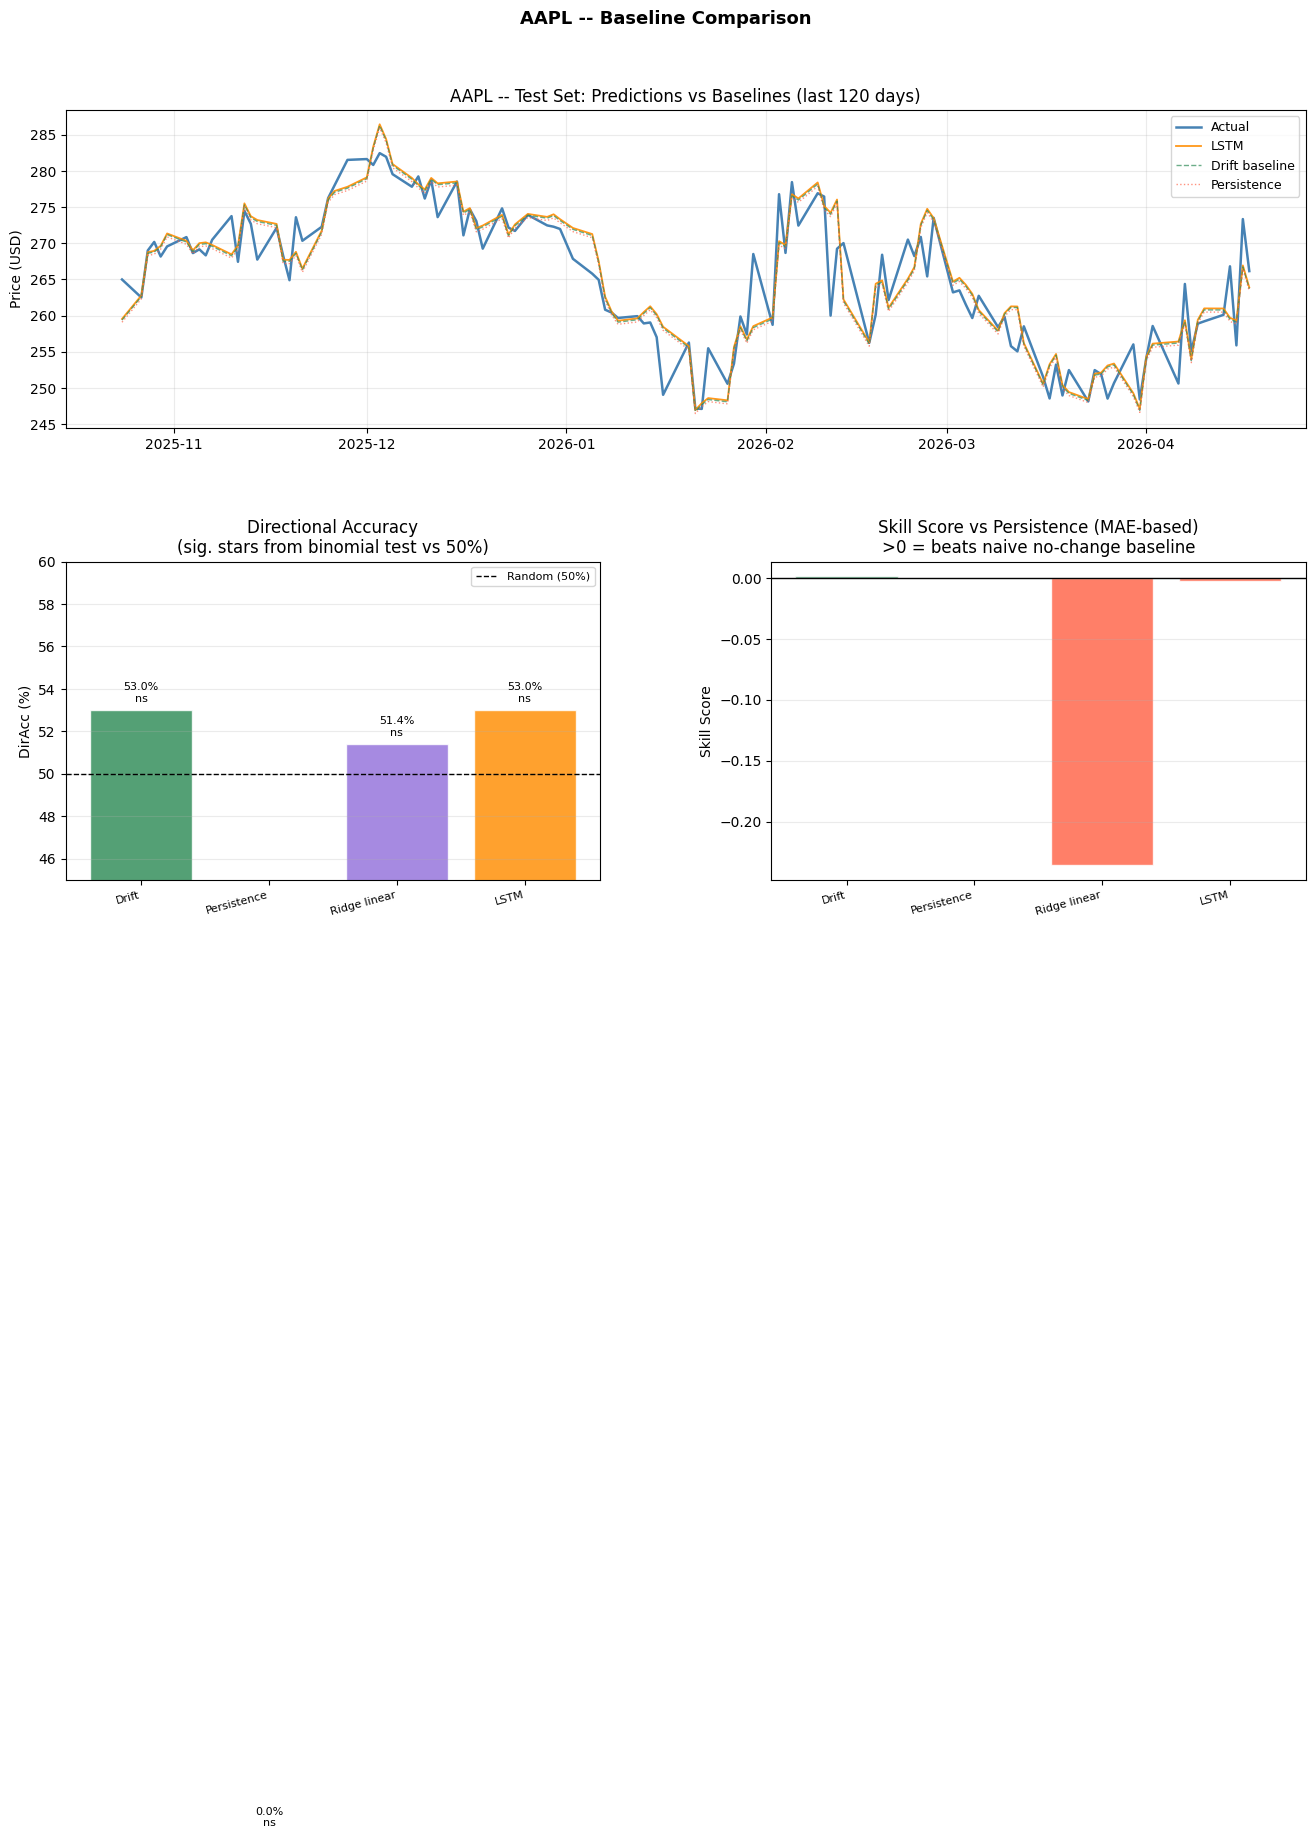

Saved: baseline_comparison_AAPL.png


In [13]:
fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.42, wspace=0.32)

# Panel A: price overlay
ax0 = fig.add_subplot(gs[0, :])
n   = min(120, len(dates_test))
ax0.plot(dates_test[-n:], p_true[-n:],    label='Actual',         lw=1.8, color='steelblue')
ax0.plot(dates_test[-n:], p_lstm[-n:],    label='LSTM',           lw=1.3, color='darkorange', alpha=0.9)
ax0.plot(dates_test[-n:], p_drift[-n:],   label='Drift baseline', lw=1.0, color='seagreen',   alpha=0.7, linestyle='--')
ax0.plot(dates_test[-n:], p_persist[-n:], label='Persistence',    lw=1.0, color='tomato',     alpha=0.7, linestyle=':')
ax0.set_title(TICKER + ' -- Test Set: Predictions vs Baselines (last {} days)'.format(n))
ax0.set_ylabel('Price (USD)')
ax0.legend(fontsize=9)
ax0.grid(alpha=0.25)

# Panel B: DirAcc bars
ax1  = fig.add_subplot(gs[1, 0])
lbls = [r['label'].split('(')[0].strip() for r in rows]
daccs = [r['DirAcc'] for r in rows]
cols  = ['seagreen', 'tomato', 'mediumpurple', 'darkorange']
bars  = ax1.bar(lbls, daccs, color=cols, alpha=0.82, edgecolor='white')
ax1.axhline(50, color='black', linestyle='--', lw=1.0, label='Random (50%)')
for bar, val, r in zip(bars, daccs, rows):
    sig = '***' if r['p-value'] < 0.001 else '**' if r['p-value'] < 0.01 \
          else '*' if r['p-value'] < 0.05 else 'ns'
    ax1.text(bar.get_x() + bar.get_width() / 2, val + 0.3,
             '{:.1f}%\n{}'.format(val, sig), ha='center', va='bottom', fontsize=8)
ax1.set_title('Directional Accuracy\n(sig. stars from binomial test vs 50%)')
ax1.set_ylabel('DirAcc (%)')
ax1.set_ylim(45, max(daccs) + 7)
ax1.legend(fontsize=8)
ax1.grid(axis='y', alpha=0.25)
plt.setp(ax1.get_xticklabels(), rotation=15, ha='right', fontsize=8)

# Panel C: Skill score bars
ax2    = fig.add_subplot(gs[1, 1])
skills = [r['Skill'] for r in rows]
bar_c  = ['seagreen' if s > 0 else 'tomato' for s in skills]
ax2.bar(lbls, skills, color=bar_c, alpha=0.82, edgecolor='white')
ax2.axhline(0, color='black', lw=1.0)
ax2.set_title('Skill Score vs Persistence (MAE-based)\n>0 = beats naive no-change baseline')
ax2.set_ylabel('Skill Score')
ax2.grid(axis='y', alpha=0.25)
plt.setp(ax2.get_xticklabels(), rotation=15, ha='right', fontsize=8)

plt.suptitle(TICKER + ' -- Baseline Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('baseline_comparison_' + TICKER + '.png', dpi=140, bbox_inches='tight')
plt.show()
print('Saved: baseline_comparison_' + TICKER + '.png')
